In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if Path.cwd().name == "notebooks":
    os.chdir("..")

print("Working dir:", os.getcwd())
from minilearn.helper import ezcols
from minilearn.preprocessing.test_train_splitfunc import train_test_split
from minilearn.preprocessing.Scaler import StandardScalerMM


Working dir: c:\Users\bradd\Project_CSE432-532\SER_Project


In [2]:
features = pd.read_csv("data/processed/features.csv")

print(features.shape)
features.head()

(2451, 496)


,filename,filepath,modality_number,modality,vocal_channel_number,vocal_channel,emotion_code,emotion,intensity_number,intensity,...,spec_centroid_min,spec_centroid_max,spec_bandwidth_mean,spec_bandwidth_std,spec_bandwidth_min,spec_bandwidth_max,spec_rolloff_mean,spec_rolloff_std,spec_rolloff_min,spec_rolloff_max
0,03-01-01-01-01-01-01.wav,data\Actor_01\03-01-01-01-01-01-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,0.000000,14584.465982,5551.291828,1966.670942,0.000000,7941.362325,13285.735887,7873.634242,0.0000,20929.6875
1,03-01-01-01-01-02-01.wav,data\Actor_01\03-01-01-01-01-02-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,850.770544,12081.525541,5653.771579,1897.506371,2300.580933,8065.492390,13191.643371,7634.107567,960.9375,21140.6250
2,03-01-01-01-02-01-01.wav,data\Actor_01\03-01-01-01-02-01-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,0.000000,12170.914340,5641.048020,2054.943735,0.000000,7938.570208,13279.137826,7981.393363,0.0000,21140.6250
3,03-01-01-01-02-02-01.wav,data\Actor_01\03-01-01-01-02-02-01.wav,3,audio-only,1,speech,1,neutral,1,normal,...,1001.254209,12108.222580,5802.315322,1915.796134,2313.602810,7918.679500,13272.074245,7570.671093,937.5000,21187.5000
4,03-01-02-01-01-01-01.wav,data\Actor_01\03-01-02-01-01-01-01.wav,3,audio-only,1,speech,2,calm,1,normal,...,0.000000,13533.883723,5518.637359,1916.039762,0.000000,8027.820710,12649.543486,7902.073642,0.0000,21585.9375


In [3]:
feature_cols = ezcols()

X = features[feature_cols]
y = features["emotion"]

print(X.shape)
print(y.value_counts())

(2451, 480)
emotion
calm         376
happy        376
sad          376
angry        376
fearful      376
surprised    192
disgust      191
neutral      188
Name: count, dtype: int64


I was close to the actual cart algorithm in the sample I took. I tried running CART against my actual dataset and got 

In [4]:
from sklearn.tree import DecisionTreeClassifier
from minilearn.classifiers.CART import CART
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=20, shuffle=True
)

scaler = StandardScalerMM()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

sample_idx = np.random.choice(len(X_train_scaled), size=500, replace=False)
X_train_sub = X_train_scaled[sample_idx]
y_train_sub = y_train[sample_idx]

skimodel = DecisionTreeClassifier(criterion='gini', max_depth=5, min_samples_split=2, random_state=20)
minilearnmodel = CART(max_depth=5, minsplit=2)

skimodel.fit(X_train_sub, y_train_sub)
minilearnmodel.fit(X_train_sub, y_train_sub)

ski_pred = skimodel.predict(X_test_scaled)
mini_pred = minilearnmodel.predict(X_test_scaled)

print("MiniLearn train accuracy:", minilearnmodel.score(X_train_sub, y_train_sub))
print("MiniLearn test accuracy:", minilearnmodel.score(X_test_scaled, y_test))

print("Sklearn train accuracy:", skimodel.score(X_train_sub, y_train_sub))
print("Sklearn test accuracy:", skimodel.score(X_test_scaled, y_test))




(1961, 480)
(490, 480)
MiniLearn train accuracy: 0.58
MiniLearn test accuracy: 0.26326530612244897
Sklearn train accuracy: 0.58
Sklearn test accuracy: 0.2836734693877551


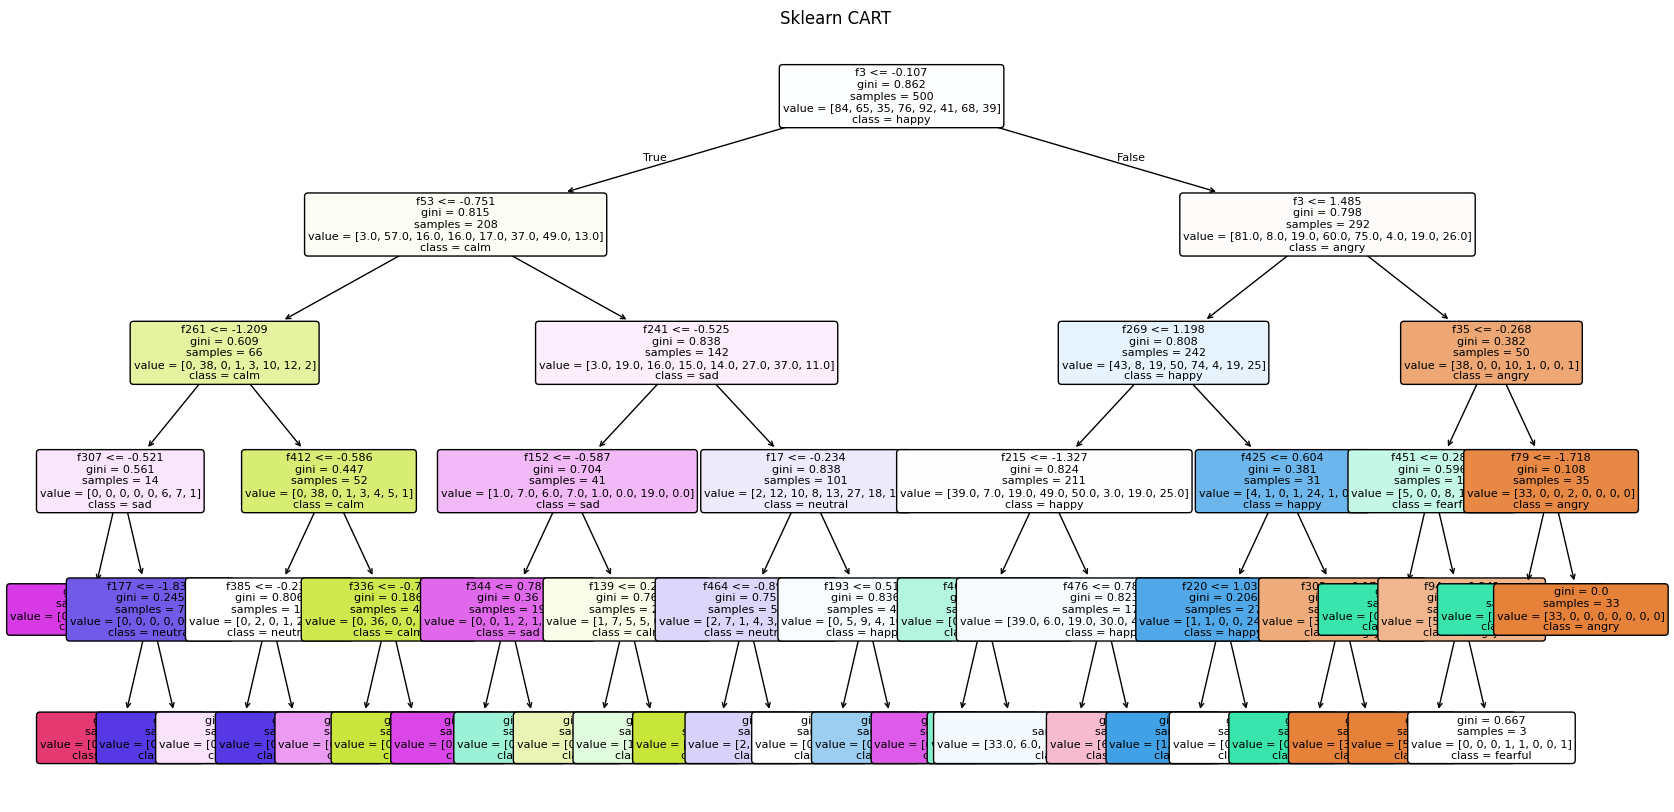

[Feature 3 <= -0.1104]
    YES → [Feature 53 <= -0.7717]
        YES → [Feature 261 <= -1.2172]
            YES → [Feature 189 <= 0.9822]
                YES → [Feature 0 <= -2.0727]
                    YES → → surprised
                    NO  → → neutral
                NO  → → sad
            NO  → [Feature 412 <= -0.5973]
                YES → [Feature 25 <= -1.0478]
                    YES → → neutral
                    NO  → → sad
                NO  → [Feature 336 <= -0.7830]
                    YES → → sad
                    NO  → → calm
        NO  → [Feature 241 <= -0.5283]
            YES → [Feature 152 <= -0.6356]
                YES → [Feature 344 <= 0.7675]
                    YES → → sad
                    NO  → → fearful
                NO  → [Feature 139 <= 0.1665]
                    YES → → calm
                    NO  → → disgust
            NO  → [Feature 17 <= -0.2533]
                YES → [Feature 2 <= -1.7570]
                    YES → → calm
               

In [5]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(skimodel, 
          filled=True, 
          feature_names=[f"f{i}" for i in range(X_train_scaled.shape[1])],
          class_names=skimodel.classes_,
          rounded=True,
          fontsize=8)
plt.title("Sklearn CART")
plt.show()

minilearnmodel.print_tree()